## Exposure at Default (EAD) Model

### Importing Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))


In [4]:
from src.preprocessing import (
    load_data,
    rename_columns,
    convert_date_columns,
    replace_never_delinquent_value,
    run_data_quality_checks,
    split_dev_validation_oot,
)

data_path = "../data/raw/dataset"

### Loading Dataset

In [5]:
loan_data = load_data(data_path)

In [6]:
loan_data = rename_columns(loan_data)
loan_data = convert_date_columns(loan_data)
loan_data = replace_never_delinquent_value(loan_data)

run_data_quality_checks(loan_data)

Duplicate rows: 0
Duplicate account-month rows: 0
INQ_12M_CNT < INQ_6M_CNT: 0
open_trades_cnt > total_trades_cnt: 0
d_dpd_max_12m_cnt < d_dpd_max_6m_cnt: 0
d_times_30dpd_12m_cnt < d_times_30dpd_6m_cnt: 0
b_curr_bal_amt > b_max_bal_12m_amt: 0
p_ontime_pay_12m_cnt > 12: 0
Invalid account dates: 0


In [7]:
loan_data.shape

(1000000, 88)

### Defining the Target Variable

The objective of this notebook is to develop an Exposure at Default (EAD) model for a credit card portfolio. We model the Credit Conversion Factor (CCF), which represents the proportion of the undrawn credit limit utilized before default. The predicted EAD can then be calculated as:

Predicted EAD = Drawn Exposure + (Predicted CCF × Undrawn Limit)

In [8]:
ead_variables = [
    "drawn_exposure_amt",
    "undrawn_limit_amt",
    "ead_amt",
]

loan_data[ead_variables].describe()

,drawn_exposure_amt,undrawn_limit_amt,ead_amt
count,1000000.000000,1000000.000000,1000000.000000
mean,2240.442115,4041.470492,126.455384
std,2513.942667,3674.818038,1091.693285
min,0.000000,0.000000,0.000000
25%,688.660000,1731.900000,0.000000
50%,1529.790000,3009.035000,0.000000
75%,2926.500000,5124.062500,0.000000
max,79002.510000,97798.540000,63268.960000


In [9]:
loan_data[ead_variables].isnull().sum()

drawn_exposure_amt    0
undrawn_limit_amt     0
ead_amt               0
dtype: int64

In [10]:
loan_data[ead_variables].head()

,drawn_exposure_amt,undrawn_limit_amt,ead_amt
0,1593.68,2981.92,0.0
1,15918.11,5365.63,0.0
2,603.18,1582.25,0.0
3,572.16,3081.47,0.0
4,4068.25,4563.73,0.0


In [11]:
# default flag
loan_data["is_currently_default"].value_counts()

is_currently_default
0    977953
1     22047
Name: count, dtype: int64

In [12]:
(loan_data["ead_amt"] > 0).value_counts()

ead_amt
False    977953
True      22047
Name: count, dtype: int64

## EAD Population

In [13]:
ead_population = loan_data[
    loan_data["is_currently_default"] == 1
].copy()

print(f"EAD population: {ead_population.shape}")

EAD population: (22047, 88)


In [14]:
# target
ead_population["ccf"] = (
    (
        ead_population["ead_amt"]
        - ead_population["drawn_exposure_amt"]
    )
    / ead_population["undrawn_limit_amt"]
)

In [15]:
ead_population["ccf"].describe()

count    20652.000000
mean         0.650081
std          0.099790
min          0.276800
25%          0.583801
50%          0.650403
75%          0.717097
max          1.000000
Name: ccf, dtype: float64

In [16]:
ead_population["ccf"].isnull().sum()

1395

In [17]:
print((ead_population["ccf"] < 0).sum())
print((ead_population["ccf"] > 1).sum())

0
1


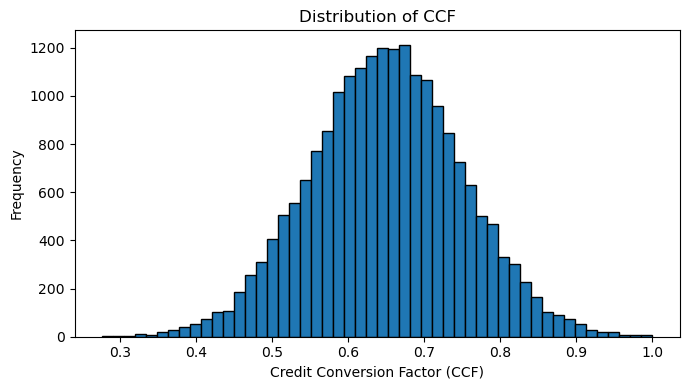

In [18]:
plt.figure(figsize=(7, 4))

plt.hist(
    ead_population["ccf"],
    bins=50,
    edgecolor="black",
)

plt.xlabel("Credit Conversion Factor (CCF)")
plt.ylabel("Frequency")
plt.title("Distribution of CCF")

plt.tight_layout()
plt.show()

In [19]:
ead_population["undrawn_limit_amt"].eq(0).sum()

1395

In [20]:
ead_population.loc[
    ead_population["undrawn_limit_amt"] == 0,
    [
        "drawn_exposure_amt",
        "undrawn_limit_amt",
        "ead_amt",
        "ccf",
    ],
].head()

,drawn_exposure_amt,undrawn_limit_amt,ead_amt,ccf
599,5249.05,0.0,5249.05,NaN
722,1744.37,0.0,1744.37,NaN
1043,3050.10,0.0,3050.10,NaN
1589,9905.22,0.0,9905.22,NaN
2852,18575.62,0.0,18575.62,NaN


Accounts with zero undrawn credit limit do not have a defined Credit Conversion Factor (CCF), as there is no available credit to convert into additional exposure before default. These observations are excluded from CCF modeling.

In [21]:
ead_population = ead_population[
    ead_population["undrawn_limit_amt"] > 0
].copy()

print(f"EAD population after removing undefined CCF: {ead_population.shape}")

EAD population after removing undefined CCF: (20652, 89)


In [22]:
ead_population["ccf"].describe()
ead_population["ccf"].isnull().sum()

0

### Development, Validation, and Out-of-Time Split

In [23]:
ead_dev, ead_validation, ead_oot = split_dev_validation_oot(
    ead_population
)

# preserve OOT identifiers for saving predictions later
oot_ids = ead_oot[
    ["acct_id", "snapshot_dt"]
].copy()

print(ead_dev.shape)
print(ead_validation.shape)
print(ead_oot.shape)


(12682, 89)
(2839, 89)
(5131, 89)


### Preprocessing

In [24]:
ead_dev.columns.tolist()

['cust_id',
 'acct_id',
 'appl_id',
 'snapshot_dt',
 'acct_open_dt',
 'portfolio_segment_cd',
 'age',
 'gender_cd',
 'marital_sts_cd',
 'emp_sts_cd',
 'emp_length_yrs',
 'annual_inc_amt',
 'residence_type_cd',
 'state_cd',
 'product_cd',
 'card_type_cd',
 'mob_cnt',
 'credit_limit_amt',
 'orig_credit_limit_amt',
 'interest_rate_pct',
 'annual_fee_amt',
 'bureau_score',
 'bureau_score_2',
 'total_trades_cnt',
 'open_trades_cnt',
 'delinq_trades_cnt',
 'inq_6m_cnt',
 'inq_12m_cnt',
 'total_debt_amt',
 'dti_ratio',
 'd_dpd_curr_cnt',
 'd_dpd_max_6m_cnt',
 'd_dpd_max_12m_cnt',
 'd_times_30dpd_6m_cnt',
 'd_times_30dpd_12m_cnt',
 'd_times_60dpd_12m_cnt',
 'd_times_90dpd_12m_cnt',
 'd_mob_since_last_delinq_cnt',
 'd_curr_delinq_bucket_cd',
 'd_ever_chgoff_flag',
 'd_cure_flag',
 'b_curr_bal_amt',
 'b_avg_bal_3m_amt',
 'b_avg_bal_6m_amt',
 'b_max_bal_12m_amt',
 'b_min_bal_12m_amt',
 'b_revolve_bal_amt',
 'b_util_ratio',
 'b_util_3m_avg_ratio',
 'b_overlimit_flag',
 's_spend_1m_amt',
 's_spend_

In [25]:
drop_columns = [
    # identifiers
    "cust_id",
    "acct_id",
    "appl_id",

    # dates
    "snapshot_dt",
    "acct_open_dt",

    # target
    "ccf",

    # target construction variables (leakage)
    "ead_amt",
    "drawn_exposure_amt",
    "undrawn_limit_amt",

    # split flag
    "dev_oot_flag",

    # existing risk scores
    "r_behav_score",
    "r_application_score",
    "r_collections_score",
    "r_attrition_score",
    "r_fraud_score",

    # PD target
    "target",
    "is_currently_default",

    # post-default information
    "default_dt",
    "days_in_default_cnt",
    "workout_status_cd",
    "recovery_amt",

    # macro variables
    "gdp_growth_rate",
    "unemployment_rate",
    "hpi_index",
    "benchmark_int_rate",
    "macro_scenario_cd",

]

In [26]:
# separating features and target
X_dev = ead_dev.drop(columns=drop_columns)
y_dev = ead_dev["ccf"]

X_validation = ead_validation.drop(columns=drop_columns)
y_validation = ead_validation["ccf"]

X_oot = ead_oot.drop(columns=drop_columns)
y_oot = ead_oot["ccf"]


In [27]:
print(X_dev.shape)
print(X_validation.shape)
print(X_oot.shape)

(12682, 63)
(2839, 63)
(5131, 63)


In [28]:
X_dev.columns.tolist()

['portfolio_segment_cd',
 'age',
 'gender_cd',
 'marital_sts_cd',
 'emp_sts_cd',
 'emp_length_yrs',
 'annual_inc_amt',
 'residence_type_cd',
 'state_cd',
 'product_cd',
 'card_type_cd',
 'mob_cnt',
 'credit_limit_amt',
 'orig_credit_limit_amt',
 'interest_rate_pct',
 'annual_fee_amt',
 'bureau_score',
 'bureau_score_2',
 'total_trades_cnt',
 'open_trades_cnt',
 'delinq_trades_cnt',
 'inq_6m_cnt',
 'inq_12m_cnt',
 'total_debt_amt',
 'dti_ratio',
 'd_dpd_curr_cnt',
 'd_dpd_max_6m_cnt',
 'd_dpd_max_12m_cnt',
 'd_times_30dpd_6m_cnt',
 'd_times_30dpd_12m_cnt',
 'd_times_60dpd_12m_cnt',
 'd_times_90dpd_12m_cnt',
 'd_mob_since_last_delinq_cnt',
 'd_curr_delinq_bucket_cd',
 'd_ever_chgoff_flag',
 'd_cure_flag',
 'b_curr_bal_amt',
 'b_avg_bal_3m_amt',
 'b_avg_bal_6m_amt',
 'b_max_bal_12m_amt',
 'b_min_bal_12m_amt',
 'b_revolve_bal_amt',
 'b_util_ratio',
 'b_util_3m_avg_ratio',
 'b_overlimit_flag',
 's_spend_1m_amt',
 's_spend_3m_amt',
 's_spend_12m_amt',
 's_txn_1m_cnt',
 's_avg_ticket_amt',
 '

### Missing Value Treatment

In [29]:
# missing value summary
missing_summary = pd.DataFrame({
    "Missing Values": X_dev.isnull().sum(),
    "Missing Percentage": (X_dev.isnull().mean() * 100),
})

missing_summary = missing_summary[
    missing_summary["Missing Values"] > 0
].sort_values(
    by="Missing Percentage",
    ascending=False,
)

missing_summary

,Missing Values,Missing Percentage
emp_length_yrs,531,4.187037
bureau_score_2,376,2.964832
p_days_since_last_pay_cnt,256,2.018609
dti_ratio,250,1.971298
d_mob_since_last_delinq_cnt,238,1.876676
collateral_value_amt,121,0.954108


In [30]:
# separating numerical and categorical features
categorical_features = X_dev.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X_dev.select_dtypes(
    include=["number"]
).columns.tolist()

print(f"Numerical features: {len(numerical_features)}")
print(f"Categorical features: {len(categorical_features)}")

Numerical features: 52
Categorical features: 11


In [31]:
X_dev[categorical_features].isnull().sum()

portfolio_segment_cd       0
gender_cd                  0
marital_sts_cd             0
emp_sts_cd                 0
residence_type_cd          0
state_cd                   0
product_cd                 0
card_type_cd               0
d_curr_delinq_bucket_cd    0
collateral_type_cd         0
data_quality_flag          0
dtype: int64

In [32]:
X_dev[numerical_features].isnull().sum()

age                              0
emp_length_yrs                 531
annual_inc_amt                   0
mob_cnt                          0
credit_limit_amt                 0
orig_credit_limit_amt            0
interest_rate_pct                0
annual_fee_amt                   0
bureau_score                     0
bureau_score_2                 376
total_trades_cnt                 0
open_trades_cnt                  0
delinq_trades_cnt                0
inq_6m_cnt                       0
inq_12m_cnt                      0
total_debt_amt                   0
dti_ratio                      250
d_dpd_curr_cnt                   0
d_dpd_max_6m_cnt                 0
d_dpd_max_12m_cnt                0
d_times_30dpd_6m_cnt             0
d_times_30dpd_12m_cnt            0
d_times_60dpd_12m_cnt            0
d_times_90dpd_12m_cnt            0
d_mob_since_last_delinq_cnt    238
d_ever_chgoff_flag               0
d_cure_flag                      0
b_curr_bal_amt                   0
b_avg_bal_3m_amt    

In [33]:
X_dev["d_mob_since_last_delinq_cnt"].value_counts(dropna=False)

d_mob_since_last_delinq_cnt
0.0    12444
NaN      238
Name: count, dtype: int64

The distribution of `d_mob_since_last_delinq_cnt` was examined before imputation. In the EAD development population, over 98% of observations had a value of `0`, indicating the variable had extremely low variance. Rather than imputing the missing values, the feature was removed because it was unlikely to provide meaningful predictive information and could introduce numerical instability in later modeling steps

In [34]:
# dropping near-constant feature
X_dev = X_dev.drop(columns="d_mob_since_last_delinq_cnt")
X_validation = X_validation.drop(columns="d_mob_since_last_delinq_cnt")
X_oot = X_oot.drop(columns="d_mob_since_last_delinq_cnt")

numerical_features.remove("d_mob_since_last_delinq_cnt")


In [35]:
# imputation
median_impute_features = [
    "emp_length_yrs",
    "bureau_score_2",
    "dti_ratio",
    "p_days_since_last_pay_cnt",
]

median_values = X_dev[median_impute_features].median()


In [36]:
X_dev[median_impute_features] = X_dev[
    median_impute_features
].fillna(median_values)

X_validation[median_impute_features] = X_validation[
    median_impute_features
].fillna(median_values)

X_oot[median_impute_features] = X_oot[
    median_impute_features
].fillna(median_values)


In [37]:
# median imputation
median_impute_features = [
    "emp_length_yrs",
    "bureau_score_2",
    "dti_ratio",
    "p_days_since_last_pay_cnt",
]

median_values = X_dev[median_impute_features].median()


In [38]:
X_dev[median_impute_features] = X_dev[
    median_impute_features
].fillna(median_values)

X_validation[median_impute_features] = X_validation[
    median_impute_features
].fillna(median_values)

X_oot[median_impute_features] = X_oot[
    median_impute_features
].fillna(median_values)


In [39]:
# collateral_value_amt imputation
secured_median = X_dev.loc[
    X_dev["secured_flag"] == 1,
    "collateral_value_amt",
].median()


In [40]:
for dataset in [X_dev, X_validation, X_oot]:

    dataset.loc[
        dataset["secured_flag"] == 0,
        "collateral_value_amt",
    ] = dataset.loc[
        dataset["secured_flag"] == 0,
        "collateral_value_amt",
    ].fillna(0)

    dataset.loc[
        dataset["secured_flag"] == 1,
        "collateral_value_amt",
    ] = dataset.loc[
        dataset["secured_flag"] == 1,
        "collateral_value_amt",
    ].fillna(secured_median)
    

In [41]:
X_dev.isnull().sum().sum(), X_validation.isnull().sum().sum(), X_oot.isnull().sum().sum()

(0, 0, 0)

In [42]:
# one-hot encoding

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False,
)

encoder.fit(X_dev[categorical_features])


,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",'first'
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_infre

In [43]:
X_dev_encoded = encoder.transform(
    X_dev[categorical_features]
)

X_validation_encoded = encoder.transform(
    X_validation[categorical_features]
)

X_oot_encoded = encoder.transform(
    X_oot[categorical_features]
)


In [44]:
encoded_columns = encoder.get_feature_names_out(
    categorical_features
)


In [45]:
X_dev_encoded = pd.DataFrame(
    X_dev_encoded,
    columns=encoded_columns,
    index=X_dev.index,
)

X_validation_encoded = pd.DataFrame(
    X_validation_encoded,
    columns=encoded_columns,
    index=X_validation.index,
)

X_oot_encoded = pd.DataFrame(
    X_oot_encoded,
    columns=encoded_columns,
    index=X_oot.index,
)


In [46]:
X_dev = pd.concat(
    [
        X_dev.drop(columns=categorical_features),
        X_dev_encoded,
    ],
    axis=1,
)

X_validation = pd.concat(
    [
        X_validation.drop(columns=categorical_features),
        X_validation_encoded,
    ],
    axis=1,
)

X_oot = pd.concat(
    [
        X_oot.drop(columns=categorical_features),
        X_oot_encoded,
    ],
    axis=1,
)


In [47]:
print(X_dev.shape)
print(X_validation.shape)
print(X_oot.shape)


(12682, 92)
(2839, 92)
(5131, 92)


## Correlation Analysis

In [48]:
# correlation matrix
correlation_matrix = X_dev.corr(numeric_only=True)

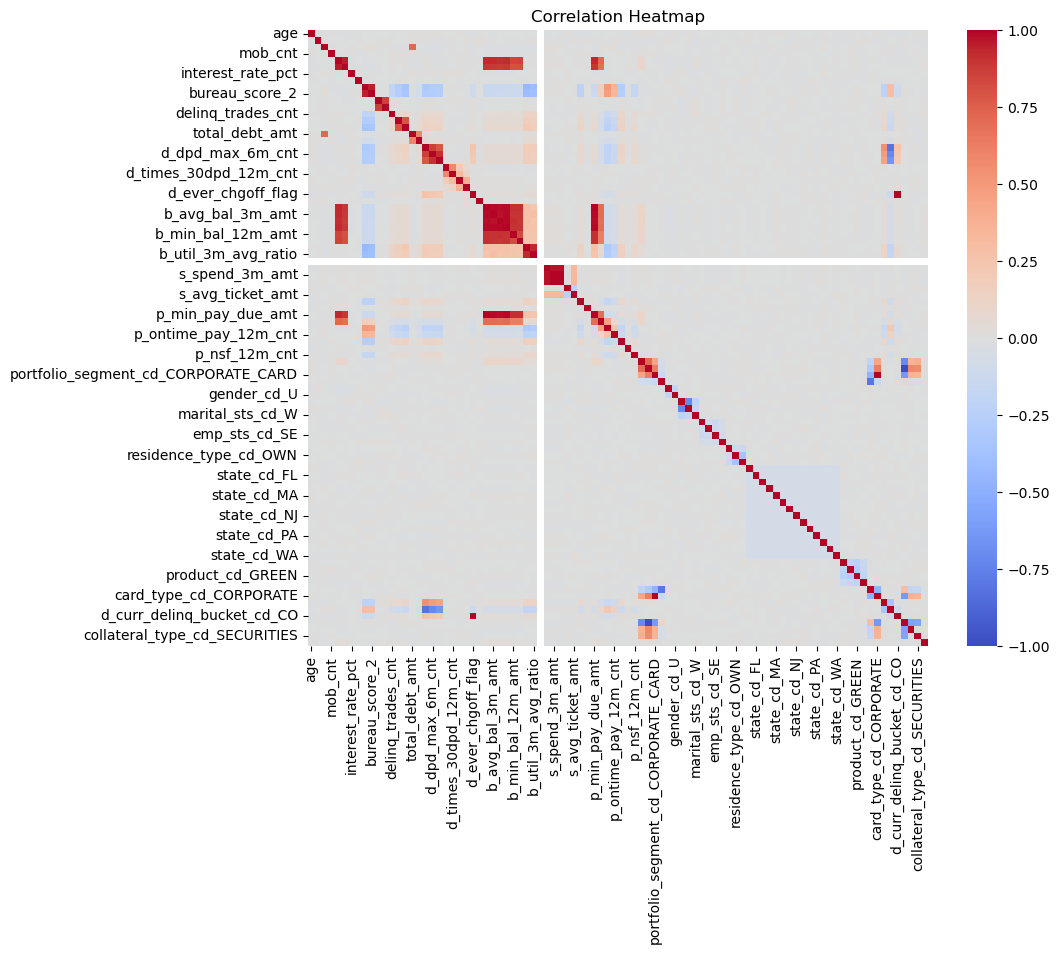

In [49]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
)

plt.title("Correlation Heatmap")

plt.show()


In [50]:
# identifying highly correlated feature pairs
corr_pairs = (
    correlation_matrix.where(
        np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
    )
    .stack()
    .reset_index()
)


In [51]:
corr_pairs.columns = [
    "feature_1",
    "feature_2",
    "correlation",
]

high_corr = (
    corr_pairs[
        corr_pairs["correlation"].abs() >= 0.80
    ]
    .sort_values(
        by="correlation",
        key=abs,
        ascending=False,
    )
)

high_corr


,feature_1,feature_2,correlation
1945,d_ever_chgoff_flag,d_curr_delinq_bucket_cd_CO,1.000000
3307,portfolio_segment_cd_CORPORATE_CARD,card_type_cd_CORPORATE,1.000000
3271,secured_flag,collateral_type_cd_NONE,-1.000000
2029,b_curr_bal_amt,p_min_pay_due_amt,0.999460
2555,s_spend_3m_amt,s_spend_12m_amt,0.994282
2015,b_curr_bal_amt,b_avg_bal_3m_amt,0.991316
2092,b_avg_bal_3m_amt,p_min_pay_due_amt,0.990790
2017,b_curr_bal_amt,b_max_bal_12m_amt,0.990007
2215,b_max_bal_12m_amt,p_min_pay_due_amt,0.989458
2080,b_avg_bal_3m_amt,b_max_bal_12m_amt,0.986301


In [52]:
# dropping highly correlated features (first pass)
drop_columns_corr = [
    # perfect correlations
    "d_curr_delinq_bucket_cd_CO",
    "card_type_cd_CORPORATE",
    "collateral_type_cd_NONE",

    # balance cluster
    "orig_credit_limit_amt",
    "b_avg_bal_3m_amt",
    "b_avg_bal_6m_amt",
    "b_max_bal_12m_amt",
    "b_min_bal_12m_amt",
    "b_revolve_bal_amt",

    # spending cluster
    "s_spend_1m_amt",
    "s_spend_12m_amt",

    # bureau
    "bureau_score_2",

    # payment
    "p_min_pay_due_amt",

    # delinquency
    "d_dpd_max_6m_cnt",
]

X_dev = X_dev.drop(columns=drop_columns_corr)
X_validation = X_validation.drop(columns=drop_columns_corr)
X_oot = X_oot.drop(columns=drop_columns_corr)

In [53]:
# recomputing correlations
correlation_matrix = X_dev.corr(numeric_only=True)

corr_pairs = (
    correlation_matrix.where(
        np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
    )
    .stack()
    .reset_index()
)

corr_pairs.columns = [
    "feature_1",
    "feature_2",
    "correlation",
]


In [54]:
high_corr = (
    corr_pairs[
        corr_pairs["correlation"].abs() >= 0.80
    ]
    .sort_values(
        by="correlation",
        key=abs,
        ascending=False,
    )
)

high_corr

,feature_1,feature_2,correlation
316,credit_limit_amt,b_curr_bal_amt,0.935551
1548,b_util_ratio,b_util_3m_avg_ratio,0.935046
580,total_trades_cnt,open_trades_cnt,0.861819
1092,d_dpd_curr_cnt,d_curr_delinq_bucket_cd_90-119,-0.818894
2290,portfolio_segment_cd_SMALL_BUS_CARD,card_type_cd_CONSUMER,-0.800818


In [55]:
# comparing correlated continuous features with the target
X_dev[
    [
        "b_util_ratio",
        "b_util_3m_avg_ratio",
        "credit_limit_amt",
        "b_curr_bal_amt",
        "total_trades_cnt",
        "open_trades_cnt",
    ]
].corrwith(y_dev).abs().sort_values(ascending=False)


credit_limit_amt       0.016374
b_curr_bal_amt         0.014979
open_trades_cnt        0.014594
b_util_ratio           0.007907
b_util_3m_avg_ratio    0.007448
total_trades_cnt       0.004844
dtype: float64

In [56]:
# comparing delinquency features with the target
X_dev[
    [
        "d_dpd_curr_cnt",
        "d_curr_delinq_bucket_cd_90-119",
    ]
].corrwith(y_dev).abs()

d_dpd_curr_cnt                    0.003612
d_curr_delinq_bucket_cd_90-119    0.001852
dtype: float64

In [57]:
# dropping additional correlated features (second pass)
second_pass_drop = [
    "b_curr_bal_amt",
    "total_trades_cnt",
    "b_util_3m_avg_ratio",
    "card_type_cd_CONSUMER",
]

drop_columns_corr += second_pass_drop

X_dev = X_dev.drop(columns=second_pass_drop)
X_validation = X_validation.drop(columns=second_pass_drop)
X_oot = X_oot.drop(columns=second_pass_drop)


In [58]:
# final correlation check
correlation_matrix = X_dev.corr(numeric_only=True)

corr_pairs = (
    correlation_matrix.where(
        np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
    )
    .stack()
    .reset_index()
)

corr_pairs.columns = [
    "feature_1",
    "feature_2",
    "correlation",
]

high_corr = (
    corr_pairs[
        corr_pairs["correlation"].abs() >= 0.80
    ]
    .sort_values(
        by="correlation",
        key=abs,
        ascending=False,
    )
)

high_corr


,feature_1,feature_2,correlation
971,d_dpd_curr_cnt,d_curr_delinq_bucket_cd_90-119,-0.818894


### VIF Analysis

In [59]:
from statsmodels.stats.outliers_influence import (
    variance_inflation_factor,
)

In [60]:
vif = pd.DataFrame()

vif["feature"] = X_dev.columns

vif["VIF"] = [
    variance_inflation_factor(
        X_dev.values,
        i,
    )
    for i in range(X_dev.shape[1])
]

vif = vif.sort_values(
    "VIF",
    ascending=False,
)

vif


c:\Users\HP\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


,feature,VIF
14,d_dpd_curr_cnt,172.471529
7,bureau_score,120.590600
15,d_dpd_max_12m_cnt,68.983266
19,d_times_90dpd_12m_cnt,63.706381
5,interest_rate_pct,27.708181
...,...,...
28,s_intl_txn_flag,1.092792
47,emp_sts_cd_UN,1.087516
40,gender_cd_U,1.087342
73,data_quality_flag_REVIEW,1.019791


In [61]:
X_dev["b_overlimit_flag"].value_counts(dropna=False)

b_overlimit_flag
0    12682
Name: count, dtype: int64

In [62]:
vif_drop_columns = [
    "b_overlimit_flag",
]

In [63]:
X_dev = X_dev.drop(columns=vif_drop_columns)
X_validation = X_validation.drop(columns=vif_drop_columns)
X_oot = X_oot.drop(columns=vif_drop_columns)


In [64]:
vif = pd.DataFrame()

vif["feature"] = X_dev.columns

vif["VIF"] = [
    variance_inflation_factor(
        X_dev.values,
        i,
    )
    for i in range(X_dev.shape[1])
]

vif = vif.sort_values(
    "VIF",
    ascending=False,
)

vif


,feature,VIF
14,d_dpd_curr_cnt,172.471529
7,bureau_score,120.590600
15,d_dpd_max_12m_cnt,68.983266
19,d_times_90dpd_12m_cnt,63.706381
5,interest_rate_pct,27.708181
...,...,...
47,residence_type_cd_OTH,1.094782
27,s_intl_txn_flag,1.092792
46,emp_sts_cd_UN,1.087516
39,gender_cd_U,1.087342


In [65]:
X_dev[
    [
        "d_dpd_curr_cnt",
        "d_dpd_max_12m_cnt",
        "d_times_90dpd_12m_cnt",
    ]
].corr()


,d_dpd_curr_cnt,d_dpd_max_12m_cnt,d_times_90dpd_12m_cnt
d_dpd_curr_cnt,1.000000,0.788034,0.005360
d_dpd_max_12m_cnt,0.788034,1.000000,0.009317
d_times_90dpd_12m_cnt,0.005360,0.009317,1.000000


In [66]:
[col for col in X_dev.columns if col.startswith("d_curr_delinq_bucket_cd")]

['d_curr_delinq_bucket_cd_150-179', 'd_curr_delinq_bucket_cd_90-119']

In [67]:
X_dev[
    [
        "d_dpd_curr_cnt",
        "d_curr_delinq_bucket_cd_90-119",
        "d_curr_delinq_bucket_cd_150-179",
    ]
].corr()


,d_dpd_curr_cnt,d_curr_delinq_bucket_cd_90-119,d_curr_delinq_bucket_cd_150-179
d_dpd_curr_cnt,1.000000,-0.818894,0.549349
d_curr_delinq_bucket_cd_90-119,-0.818894,1.000000,-0.353098
d_curr_delinq_bucket_cd_150-179,0.549349,-0.353098,1.000000


In [68]:
X_dev[
    [
        "bureau_score",
        "interest_rate_pct",
        "credit_limit_amt",
        "annual_fee_amt",
    ]
].corr()


,bureau_score,interest_rate_pct,credit_limit_amt,annual_fee_amt
bureau_score,1.000000,0.004347,-0.017652,0.005175
interest_rate_pct,0.004347,1.000000,-0.008916,-0.005406
credit_limit_amt,-0.017652,-0.008916,1.000000,-0.000365
annual_fee_amt,0.005175,-0.005406,-0.000365,1.000000


In [69]:
vif.head(15)

,feature,VIF
14,d_dpd_curr_cnt,172.471529
7,bureau_score,120.590600
15,d_dpd_max_12m_cnt,68.983266
19,d_times_90dpd_12m_cnt,63.706381
5,interest_rate_pct,27.708181
22,b_util_ratio,26.003300
2,annual_inc_amt,19.367469
30,p_ontime_pay_12m_cnt,19.357003
12,total_debt_amt,19.105795
13,dti_ratio,18.960736


In [70]:
X_dev.shape

(12682, 73)

In [71]:
np.linalg.matrix_rank(X_dev)

73

### Model Development

In [72]:
y_dev.describe()

count    12682.000000
mean         0.650435
std          0.100077
min          0.276800
25%          0.583921
50%          0.650998
75%          0.717798
max          1.000000
Name: ccf, dtype: float64

In [73]:
print((y_dev <= 0).sum())
print((y_dev >= 1).sum())

0
2


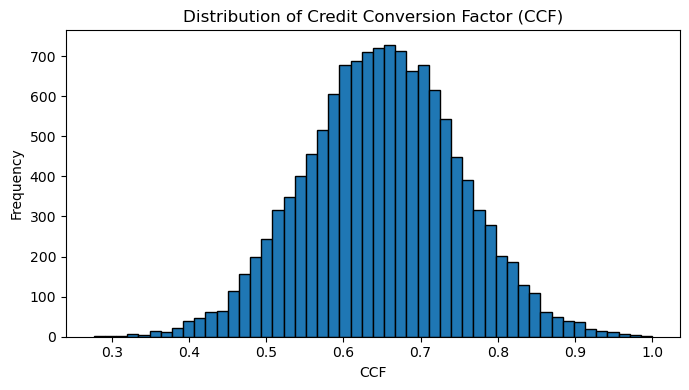

In [74]:
plt.figure(figsize=(7, 4))

plt.hist(
    y_dev,
    bins=50,
    edgecolor="black",
)

plt.xlabel("CCF")
plt.ylabel("Frequency")
plt.title("Distribution of Credit Conversion Factor (CCF)")

plt.tight_layout()
plt.show()


### Feature Scaling

Since Beta Regression requires the response variable to lie strictly within the interval (0, 1), the target variable was adjusted using the Smithson and Verkuilen (2006) transformation to accommodate the two observations with CCF = 1 while preserving the overall distribution.

Feature scaling was applied to the numerical predictors before model development. Scaling improves numerical stability during maximum likelihood estimation and helps the Beta Regression optimizer converge more reliably. The scaler was fitted on the development dataset and then applied to the validation and out-of-time datasets to prevent data leakage.

In [75]:
# target transformation
n = len(y_dev)

y_dev_beta = (
    y_dev * (n - 1) + 0.5
) / n

y_validation_beta = (
    y_validation * (n - 1) + 0.5
) / n

y_oot_beta = (
    y_oot * (n - 1) + 0.5
) / n

print(y_dev_beta.min(), y_dev_beta.max())
print(y_validation_beta.min(), y_validation_beta.max())
print(y_oot_beta.min(), y_oot_beta.max())


0.2768177466868581 0.9999605740419495
0.32291271433788604 0.9898643935963786
0.28121914963246303 0.999960574041949


In [76]:
from sklearn.preprocessing import StandardScaler

In [77]:
# identifying numerical features 
numerical_features = X_dev.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()


In [78]:
#feature scaling
scaler = StandardScaler()

X_dev_scaled = X_dev.copy()
X_validation_scaled = X_validation.copy()
X_oot_scaled = X_oot.copy()


In [79]:
X_dev_scaled[numerical_features] = scaler.fit_transform(
    X_dev[numerical_features]
)

X_validation_scaled[numerical_features] = scaler.transform(
    X_validation[numerical_features]
)

X_oot_scaled[numerical_features] = scaler.transform(
    X_oot[numerical_features]
)


In [80]:
# adding intercept
import statsmodels.api as sm

X_dev_beta = sm.add_constant(X_dev_scaled)
X_validation_beta = sm.add_constant(X_validation_scaled)
X_oot_beta = sm.add_constant(X_oot_scaled)


In [81]:
from statsmodels.othermod.betareg import BetaModel

beta_model = BetaModel(
    endog=y_dev_beta,
    exog=X_dev_beta,
)

beta_results = beta_model.fit()

print(beta_results.summary())

                              BetaModel Results                               
Dep. Variable:                    ccf   Log-Likelihood:                 10951.
Model:                      BetaModel   AIC:                        -2.175e+04
Method:            Maximum Likelihood   BIC:                        -2.119e+04
Date:                Mon, 10 Aug 2026                                         
Time:                        02:02:37                                         
No. Observations:               12682                                         
Df Residuals:                   12607                                         
Df Model:                          73                                         
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
const                                   0.6245      0.004    155.215      0.000  

In [82]:
# check convergence
beta_results.mle_retvals["converged"]


True

In [83]:
# predictions
y_dev_pred = beta_results.predict(X_dev_beta)

y_validation_pred = beta_results.predict(
    X_validation_beta
)

y_oot_pred = beta_results.predict(
    X_oot_beta
)


### Model Evaluation

In [84]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from scipy.stats import spearmanr


In [85]:
def evaluate_model(y_true, y_pred, dataset_name):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    spearman = spearmanr(y_true, y_pred).statistic

    print(f"\n{dataset_name}")
    print(f"MAE      : {mae:.4f}")
    print(f"RMSE     : {rmse:.4f}")
    print(f"R²       : {r2:.4f}")
    print(f"Spearman : {spearman:.4f}")
    

In [86]:
evaluate_model(
    y_dev,
    y_dev_pred,
    "Development",
)

evaluate_model(
    y_validation,
    y_validation_pred,
    "Validation",
)

evaluate_model(
    y_oot,
    y_oot_pred,
    "Out-of-Time",
)


Development
MAE      : 0.0794
RMSE     : 0.0997
R²       : 0.0069
Spearman : 0.0769

Validation
MAE      : 0.0785
RMSE     : 0.0989
R²       : -0.0095
Spearman : -0.0094

Out-of-Time
MAE      : 0.0796
RMSE     : 0.1002
R²       : -0.0082
Spearman : 0.0020


### Baseline Benchmark

To assess whether the Beta Regression model provides value beyond a simple business rule, comparing its performance with a segment-level baseline. The baseline predicts the average Credit Conversion Factor (CCF) for each portfolio segment observed in the development dataset.

In [87]:
baseline_ccf = (
    ead_dev
    .assign(ccf=y_dev)
    .groupby("portfolio_segment_cd")["ccf"]
    .mean()
)

baseline_ccf

portfolio_segment_cd
CONSUMER_CARD     0.649197
CORPORATE_CARD    0.654504
SMALL_BUS_CARD    0.653275
Name: ccf, dtype: float64

In [88]:
baseline_dev_pred = (
    ead_dev["portfolio_segment_cd"]
    .map(baseline_ccf)
)

baseline_validation_pred = (
    ead_validation["portfolio_segment_cd"]
    .map(baseline_ccf)
)

baseline_oot_pred = (
    ead_oot["portfolio_segment_cd"]
    .map(baseline_ccf)
)


In [89]:
evaluate_model(
    y_dev,
    baseline_dev_pred,
    "Baseline - Development",
)

evaluate_model(
    y_validation,
    baseline_validation_pred,
    "Baseline - Validation",
)

evaluate_model(
    y_oot,
    baseline_oot_pred,
    "Baseline - Out-of-Time",
)



Baseline - Development
MAE      : 0.0797
RMSE     : 0.1001
R²       : 0.0004
Spearman : 0.0210

Baseline - Validation
MAE      : 0.0781
RMSE     : 0.0985
R²       : -0.0003
Spearman : -0.0041

Baseline - Out-of-Time
MAE      : 0.0794
RMSE     : 0.0999
R²       : -0.0014
Spearman : -0.0211


### Actual vs Predicted

The scatter plot compares the observed CCF values with the Beta Regression predictions. A well-performing model would produce points clustered around the 45-degree reference line, indicating close agreement between predicted and observed values

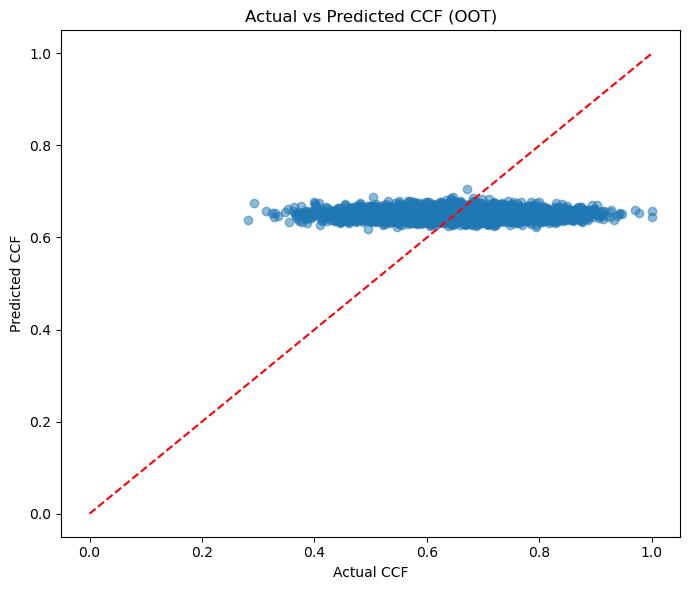

In [90]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_oot,
    y_oot_pred,
    alpha=0.5,
)

plt.plot(
    [0, 1],
    [0, 1],
    color="red",
    linestyle="--",
)

plt.xlabel("Actual CCF")
plt.ylabel("Predicted CCF")
plt.title("Actual vs Predicted CCF (OOT)")

plt.tight_layout()
plt.show()

### Residual Analysis

Performing residual analysis to assess the prediction errors of the Beta Regression model

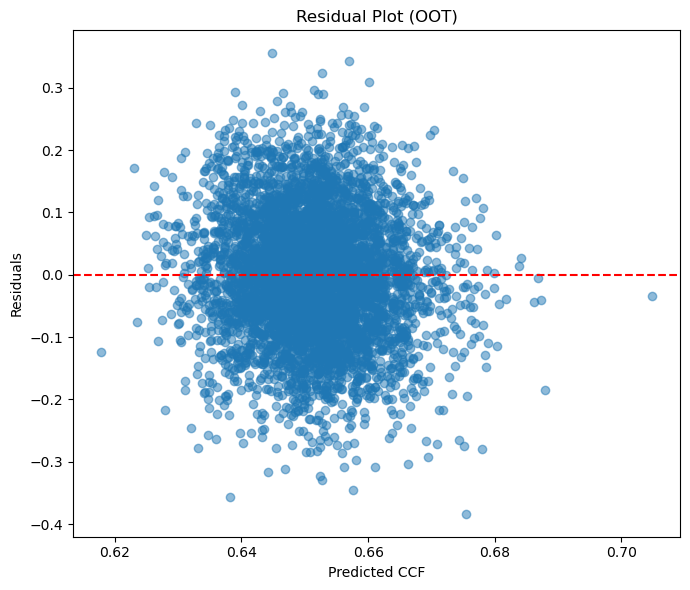

In [91]:
residuals = y_oot - y_oot_pred

plt.figure(figsize=(7, 6))

plt.scatter(
    y_oot_pred,
    residuals,
    alpha=0.5,
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
)

plt.xlabel("Predicted CCF")
plt.ylabel("Residuals")
plt.title("Residual Plot (OOT)")

plt.tight_layout()
plt.show()

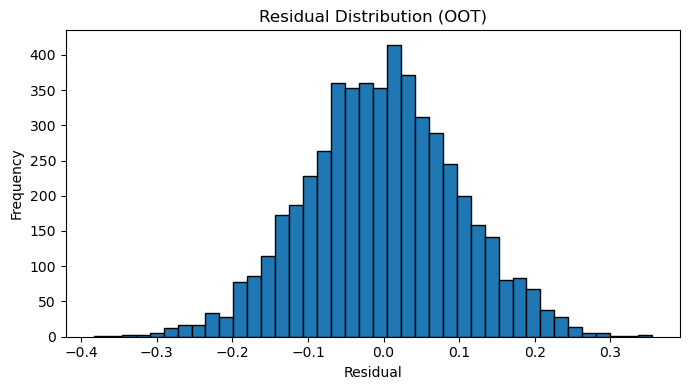

In [92]:
plt.figure(figsize=(7, 4))

plt.hist(
    residuals,
    bins=40,
    edgecolor="black",
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution (OOT)")

plt.tight_layout()
plt.show()


### Feature Importance

In [93]:
feature_importance = pd.DataFrame(
    {
        "Feature": X_dev_beta.columns,
        "Coefficient": beta_results.params[:-1],
        "P-Value": beta_results.pvalues[:-1],
    }
)

feature_importance = feature_importance[feature_importance["Feature"] != "const"]

feature_importance = feature_importance[
    feature_importance["P-Value"] < 0.05
].sort_values(
    by="Coefficient",
    key=np.abs,
    ascending=False,
)

feature_importance

,Feature,Coefficient,P-Value
state_cd_CA,state_cd_CA,-0.015625,0.005504
product_cd_GOLD,product_cd_GOLD,-0.012551,0.006760
d_times_90dpd_12m_cnt,d_times_90dpd_12m_cnt,0.011345,0.009366
mob_cnt,mob_cnt,-0.009557,0.017267
p_nsf_12m_cnt,p_nsf_12m_cnt,-0.009277,0.022509


In [94]:
ead_pred = (
    ead_oot["drawn_exposure_amt"]
    + (baseline_oot_pred.values * ead_oot["undrawn_limit_amt"])
)

ead_predictions = oot_ids.copy()

ead_predictions["ead_pred"] = ead_pred

ead_predictions.to_csv(
    "../data/processed/ead_predictions.csv",
    index=False,
)


In [95]:
import pickle

segment_ccf = (
    ead_dev
    .assign(ccf=y_dev)
    .groupby("portfolio_segment_cd")["ccf"]
    .mean()
)

with open("../saved_objects/segment_average_ccf.pkl", "wb") as f:
    pickle.dump(segment_ccf, f)

### Conclusion

This notebook developed an Exposure at Default (EAD) model by estimating the Credit Conversion Factor (CCF) using Beta Regression. The target variable was constructed from the proportion of undrawn credit converted into exposure at default, and only currently defaulted accounts with valid CCF values were included in the modeling population.

The development process included missing value treatment, one-hot encoding, correlation analysis, multicollinearity reduction, feature scaling, and Beta Regression model fitting. Feature scaling enabled successful model convergence while maintaining a consistent modeling workflow with the PD and LGD notebooks.

Model performance was evaluated on the development, validation, and out-of-time datasets using MAE, RMSE, R², and Spearman correlation. Although the model converged successfully, it demonstrated limited predictive performance, with R² values close to zero and minimal rank-ordering ability across all datasets. This outcome was consistent with the weak relationships observed between the available predictors and the CCF target during exploratory analysis.

To assess whether the regression model provided value beyond a simple business rule, its performance was compared with a portfolio segment-level average CCF benchmark. The benchmark performed similarly to, and slightly better than, the Beta Regression model on the validation and out-of-time datasets, indicating that the available predictors contributed little incremental information for estimating account-level CCF in this dataset.

Overall, the results suggest that the available variables contain limited predictive signal for modeling individual CCF values. The notebook demonstrates a complete and reproducible EAD modeling workflow while highlighting the importance of benchmarking predictive models against simple business baselines before deploying more complex approaches.
